In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
df= pd.read_parquet('../data/processed/tablon_analitico.parquet')
df_diario= pd.read_parquet('../data/processed/tablon_analitico_diario.parquet')

### Análisis de Irradiacion y Temperatura en plantas 1 y 2
- Los análisis van a realizarse de forma ordenada según el propio ciclo de generación de energía solar fotovoltaica: captación > Potencia DC > Potencia AC y Energia total generada.

In [20]:
#df reducido para evitar evitar trabajar con datos duplicados (Irradiacion y temperatura no dependen de Inversores): filtramos en 2 inversores
df_reducido = df.loc[(df['id_inversor'] == '1BY6WEcLGh8j5v7') | (df['id_inversor'] == 'xMbIugepa2P7lBB'), 'id_planta':'temperatura_modulo_c']

In [21]:
#dataset temporal para heatmap de irradiacion por horas planta 1 y 2
irradiacion_hora_planta = df_reducido.pivot_table(
    index='hora',
    columns='id_planta',
    values='irradiacion_wh_m2',
    aggfunc='sum'
)
irradiacion_hora_planta.head(5)

id_planta,p1,p2
hora,,
0,0.0,0.000102
1,0.0,0.000106
2,0.0,0.000115
3,0.0,0.000344
4,0.0,0.000526


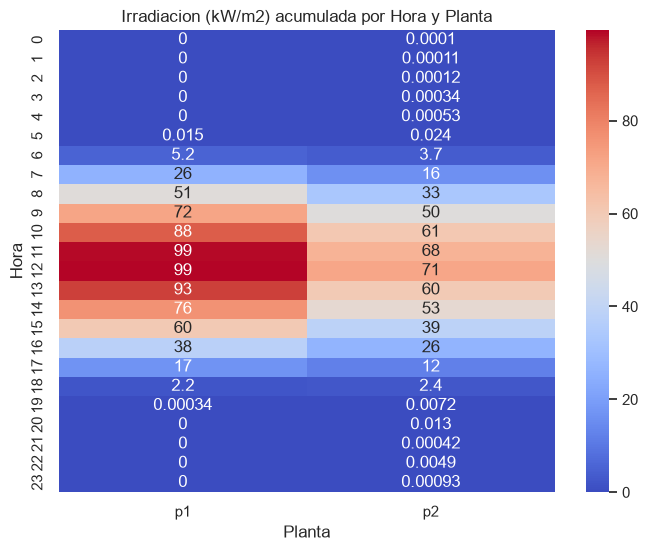

In [62]:
#Heatmap de Irradiacion acumulada en plantas 1 y 2 por hora
plt.figure(figsize=(8, 6))
sns.heatmap(irradiacion_hora_planta, annot=True, cmap="coolwarm")
plt.title("Irradiacion (kW/m2) acumulada por Hora y Planta")
plt.xlabel("Planta")
plt.ylabel("Hora")
plt.show()

In [23]:
#dataset temporal para heatmap de temperatura por horas planta 1 y 2
temp_hora_planta = df_reducido.pivot_table(
    index='hora',
    columns='id_planta',
    values='temperatura_modulo_c',
    aggfunc='mean'
)
temp_hora_planta.head(5)

id_planta,p1,p2
hora,,
0,20.991789,23.549090
1,20.873304,23.283674
2,20.766690,22.934589
3,20.624820,22.765321
4,20.469069,22.703041


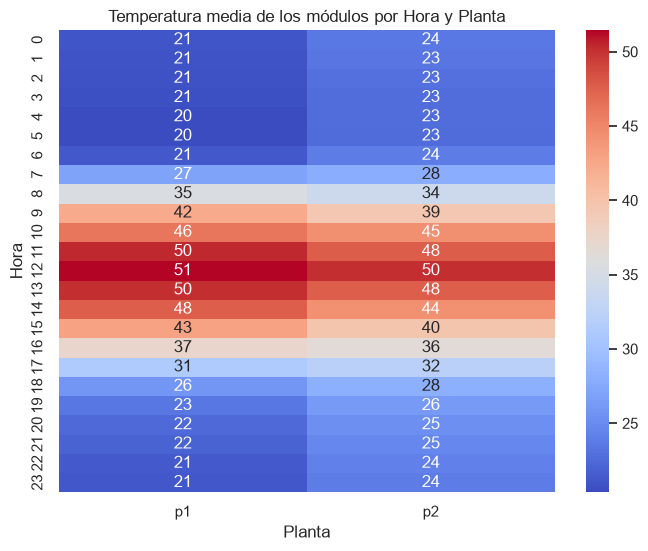

In [63]:
#Visualización de temperatura media por hora y planta
plt.figure(figsize=(8,6))
sns.heatmap(temp_hora_planta, annot=True, cmap="coolwarm")
plt.title("Temperatura media de los módulos por Hora y Planta")
plt.xlabel("Planta")
plt.ylabel("Hora")
plt.show()

Por ahora **no se detectan anomalías** de media en valores de irradiación y temperatura para ambas plantas. A continuación se realizará un **analisis por fecha, hora y planta para detectar posibles gaps y anomalías de medición.**

In [ ]:
#Construir variable fecha a partir del indice
df_reducido['fecha'] = pd.to_datetime(df_reducido.index).date
df_reducido.head()

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,fecha
fecha_hora,,,,,,,,,,,,
2020-05-15 00:00:00,p1,1BY6WEcLGh8j5v7,HmiyD2TTLFNqkNe,5,15,00:00:00,0,0,0.0,25.184316,22.857507,2020-05-15
2020-05-15 00:15:00,p1,1BY6WEcLGh8j5v7,HmiyD2TTLFNqkNe,5,15,00:15:00,0,15,0.0,25.084589,22.761668,2020-05-15
2020-05-15 00:30:00,p1,1BY6WEcLGh8j5v7,HmiyD2TTLFNqkNe,5,15,00:30:00,0,30,0.0,24.935753,22.592306,2020-05-15
2020-05-15 00:45:00,p1,1BY6WEcLGh8j5v7,HmiyD2TTLFNqkNe,5,15,00:45:00,0,45,0.0,24.846130,22.360852,2020-05-15
2020-05-15 01:00:00,p1,1BY6WEcLGh8j5v7,HmiyD2TTLFNqkNe,5,15,01:00:00,1,0,0.0,24.621525,22.165423,2020-05-15


In [29]:
#datasets temporales para generar los heatmaps

irradiacion_temp_p1 = df_reducido[df_reducido['id_planta'] == 'p1'].pivot_table(
    index='fecha',
    columns='hora',
    values='irradiacion_wh_m2',
    aggfunc='mean'
)

irradiacion_temp_p2 = df_reducido[df_reducido['id_planta'] == 'p2'].pivot_table(
    index='fecha',
    columns='hora',
    values='irradiacion_wh_m2',
    aggfunc='mean'
)

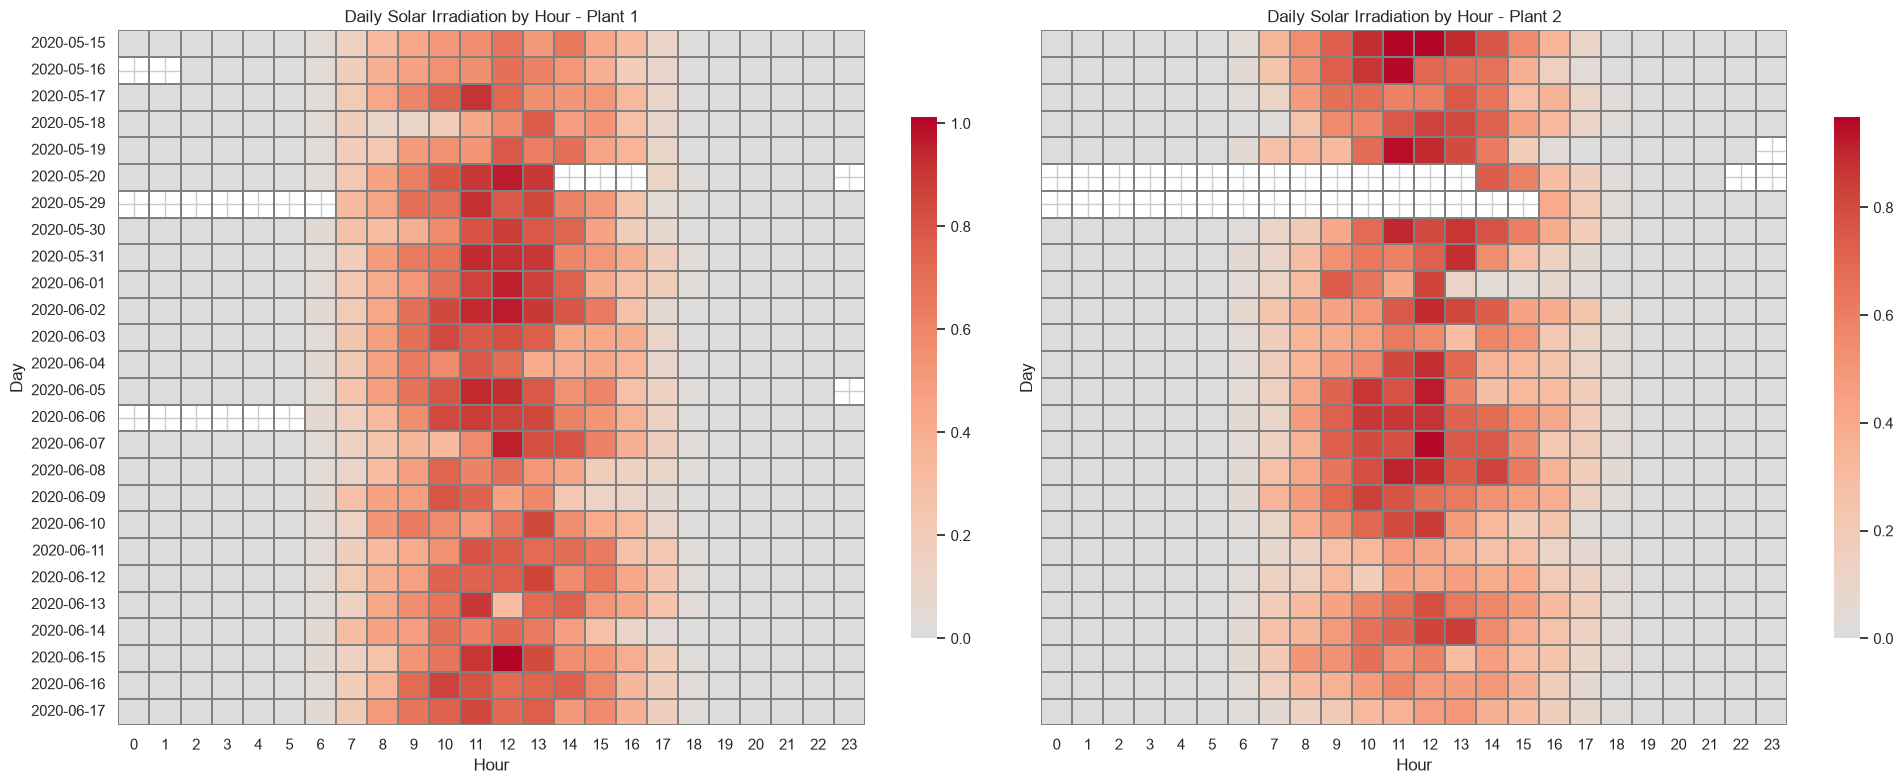

In [35]:
#Heatmaps de irradiacion diaria por horas plantas 1 y 2

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

heatmaps = {
    "Plant 1": irradiacion_temp_p1,
    "Plant 2": irradiacion_temp_p2,
}

for ax, (title, data) in zip(axes, heatmaps.items()):
    sns.heatmap(
        data,
        ax=ax,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.2,
        linecolor="gray",
        cbar_kws={"shrink": 0.75},
        yticklabels=True
    )

    ax.set_title(f"Daily Solar Irradiation by Hour - {title}", fontsize=12)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Day")

plt.tight_layout()
plt.show()

### Insight 4: Analisis de irradiacion solar en plantas 1 y 2

**Se ha identificado falta de datos de captacion y datos anómalos en ambas plantas:**
- Planta 1: falta de datos parciales los días 2020-05-16, 2020-05-20, 2020-05-21, 2020-05-28 y 2020-05-29.
- Planta 2: falta de datos parciales los días 2020-05-29, 2020-05-20 y 2020-05-29. Falta de datos completos: del 2020-05-21 al 2020-05-28.
- La ausencia de datos es aun incierta pero todo apunta a fallos en los sensores de irradiación, ya que si que se genera potencia DC.

#### Irradiacion VS potencia DC
- Se va a hacer un análisis de Irradiación VS Potencia DC para detectar posibles anomalías y descorrelaciones.

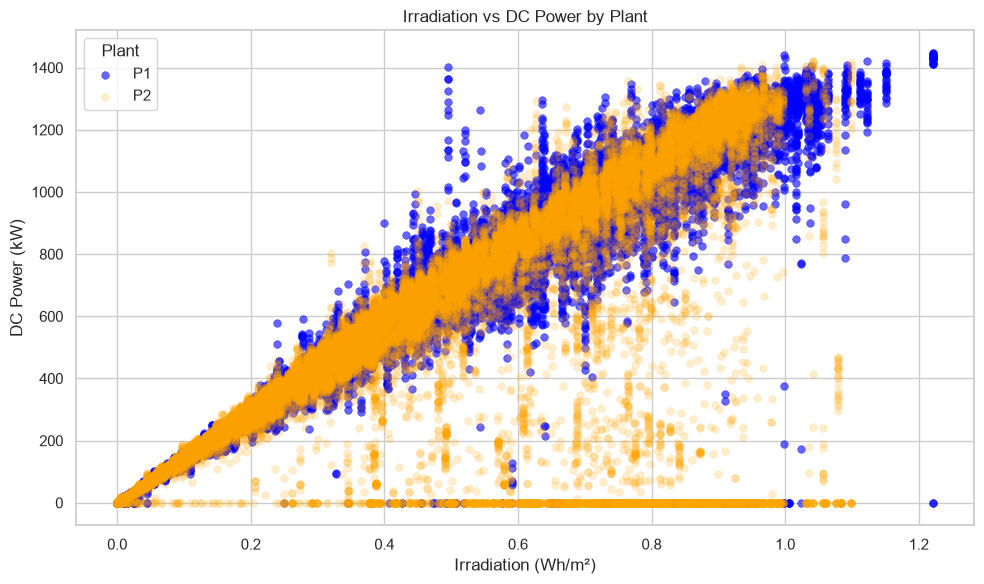

In [134]:
# Scatter superpuesto entre irradiacion y potencia DC por planta

plt.figure(figsize=(10, 6))

colors = {
    "p1": "blue",
    "p2": "orange",
}

alphas = {
    "p1": 0.6,
    "p2": 0.2,
}

for plant in ["p1", "p2"]:
    data_plant = (
        df[df["id_planta"] == plant]
        .reset_index(drop=True)
    )

    sns.scatterplot(
        data=data_plant,
        x="irradiacion_wh_m2",
        y="potencia_dc_kw",
        color=colors[plant],
        alpha=alphas[plant],
        label=plant.upper(),
        s=30,
        edgecolor=None
    )

plt.legend(title="Plant")
plt.xlabel("Irradiation (Wh/m²)")
plt.ylabel("DC Power (kW)")
plt.title("Irradiation vs DC Power by Plant")
plt.tight_layout()
plt.show()

- En la planta 2 se observa una **descorrelacion destacable entre Irradiación y Potencia**. Se analizará la **correlación entre Potencia DC y AC** para comprovar si existe problema en la **transformación de potencia**.

In [137]:
df_anomalos.head()

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,fecha
fecha_hora,,,,,,,,,,,,,,,,,
2020-05-15 09:15:00,p1,zVJPv84UY57bAof,HmiyD2TTLFNqkNe,5,15,09:15:00,9,15,0.344884,27.988362,46.617706,0.0,100.0,0.0,711.0,7116862.0,2020-05-15
2020-05-15 09:30:00,p1,zVJPv84UY57bAof,HmiyD2TTLFNqkNe,5,15,09:30:00,9,30,0.249248,27.516728,39.136326,0.0,100.0,0.0,711.0,7116862.0,2020-05-15
2020-05-24 15:15:00,p1,zBIq5rxdHJRwDNY,HmiyD2TTLFNqkNe,5,24,15:15:00,15,15,0.476600,33.761304,54.006864,0.0,100.0,0.0,6464.0,6410945.0,2020-05-24
2020-05-25 10:15:00,p1,ih0vzX44oOqAx2f,HmiyD2TTLFNqkNe,5,25,10:15:00,10,15,0.834157,29.217751,53.501414,0.0,100.0,0.0,1795.0,6258289.0,2020-05-25
2020-06-07 12:15:00,p1,bvBOhCH3iADSZry,HmiyD2TTLFNqkNe,6,7,12:15:00,12,15,1.024229,28.748334,59.987771,0.0,100.0,0.0,3551.0,6476675.0,2020-06-07


In [ ]:
#Pearson y Spearman entre potencia DC y potencia AC en planta 2 solo en puntos anómalos
irradiacion_umbral = 0.2
potencia_umbral = 50

df_anomalos = df[(df['irradiacion_wh_m2'] >= irradiacion_umbral) &
                 (df['potencia_dc_kw'] <= potencia_umbral)
].copy()

df_corr = df_anomalos[["potencia_dc_kw","potencia_ac_kw"]].dropna()

pearson_corr = df_corr["potencia_dc_kw"].corr(
    df_corr["potencia_ac_kw"],
    method="pearson"
)

spearman_corr = df_corr["potencia_dc_kw"].corr(
    df_corr["potencia_ac_kw"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Pearson strength 0-1: {abs(pearson_corr):.3f}")

print(f"Spearman correlation: {spearman_corr:.3f}")
print(f"Spearman strength 0-1: {abs(spearman_corr):.3f}")

Pearson correlation: 1.000
Pearson strength 0-1: 1.000
Spearman correlation: 1.000
Spearman strength 0-1: 1.000


- **Existe correlación entre Potencia DC y AC en valores anómalos**, lo cual **descarta fallos en la transformación de Potencia**, aunque no se puede determinar aun el origen de las anomalías.

#### Irradiacion vs Energia generada 
- Se va a analizar la irradiación (suma) respecto a la energia total generada (max.) a nivel diario para detectar posibles fallos de medición de los sensores de irradiación.

In [67]:
# df diario de irradiacion vs energia generada
df_diario_irradiacion_energia = (
    df
    .reset_index()
    .assign(fecha_dia=lambda x: x['fecha_hora'].dt.date)
    .groupby(['id_planta','fecha_dia'])[['irradiacion_wh_m2','energia_diaria_kwh']]
    .agg({
          'irradiacion_wh_m2': 'sum',
          'energia_diaria_kwh': 'max'
      })
    .reset_index()
)

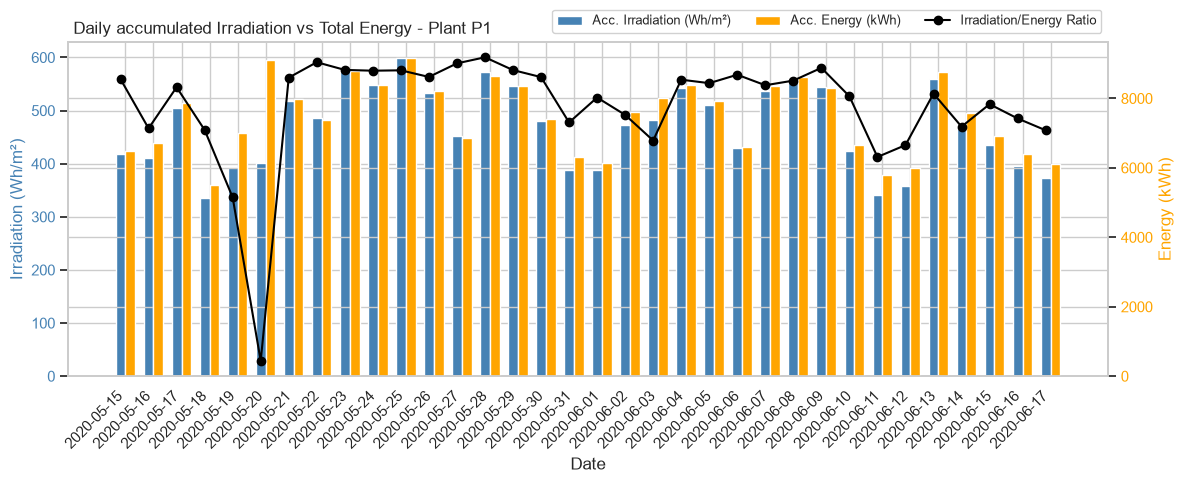

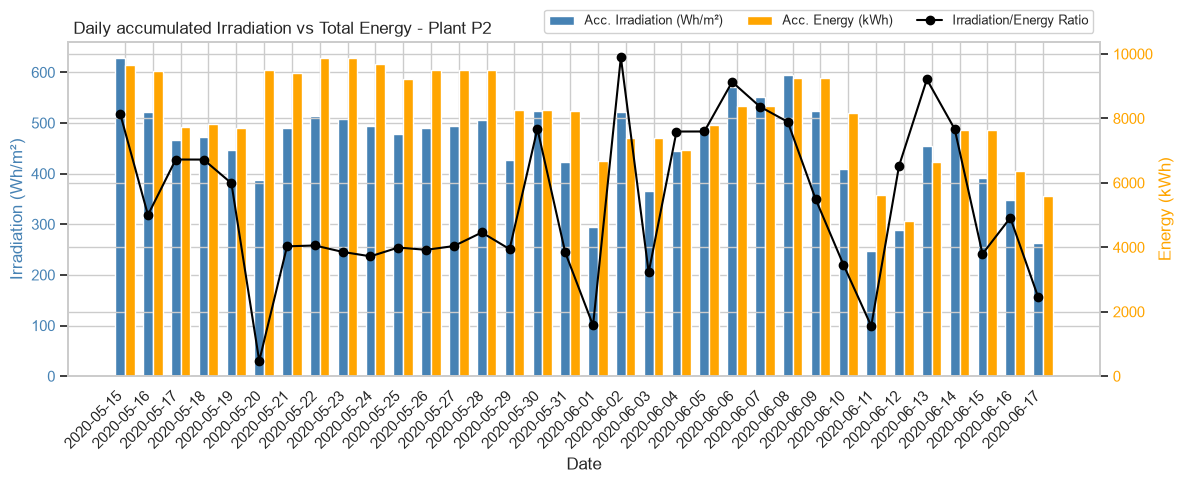

In [142]:
#Irradiacion vs Energia Generada por planta

#Ratio Irradiacion/Energia
df_diario_irradiacion_energia['ratio_irradiacion_energia'] = (
df_diario_irradiacion_energia['irradiacion_wh_m2'] / df_diario_irradiacion_energia['energia_diaria_kwh'] * 100 )

#Barplot con linea de Ratio
for planta in ['p1', 'p2']:
    df_plot = df_diario_irradiacion_energia[df_diario_irradiacion_energia['id_planta'] == planta]
    expected_ratio = {'p1': 6.52, 'p2': 6.35}

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.axis('off')

    bar_width = 0.35
    x = range(len(df_plot))

    ax1.bar(x, df_plot['irradiacion_wh_m2'], width=bar_width, label='Irradiación (Wh/m²)', color='steelblue')
    ax1.set_ylabel("Irradiation (Wh/m²)", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2.bar([p + bar_width for p in x], df_plot['energia_diaria_kwh'], width=bar_width, label='Energía (kWh)', color='orange')
    ax2.set_ylabel("Energy (kWh)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    line_ratio, = ax3.plot(x, df_plot['ratio_irradiacion_energia'], 'o-', color='black', label='Ratio Irradiación/Energía')

    ax1.set_xlabel("Date")
    # Tick centrado entre las dos barras
    ax1.set_xticks([p + bar_width/2 for p in x])
    ax1.set_xticklabels(df_plot['fecha_dia'], rotation=45, ha='right')

    handles = [ax1.patches[0], ax2.patches[0], line_ratio]
    labels = ['Acc. Irradiation (Wh/m²)', 'Acc. Energy (kWh)', 'Irradiation/Energy Ratio']
    ax1.legend(handles, labels, loc='lower right',
               bbox_to_anchor=(1.0, 1.01),  # justo debajo del título, pegado a la derecha
               ncol=3, framealpha=0.9, fontsize=9)

    ax1.set_title(f" Daily accumulated Irradiation vs Total Energy - Plant {planta.upper()}", loc='left')
    plt.tight_layout()
    plt.show()

### Insight 5: Existen fallos en los sensores de medición de irradiación solar

Debido a que existen tramos sin registro de irradiación pero si existe energia generada, los fallos provienen de los equipos de medición de irradiación.

1. Planta 1: Existen ciertas anomalías entre irradiación y energia generada en los días 18, 19 y 20 de Mayo.
2. Planta 2: Se observan numerosas anomalías de medición de irradiación en diversos días. Los mas destacables son: 16 de Mayo, 20 al 29 de Mayo, 1 de Junio, 3 de Junio, 9 a 11 de Junio y 15 a 17 de Junio.


### Analisis de Potencia VS Energia
Para el analisis de captacion de potencia de los inverters, lo dividiremos en dos partes:
1. Análisis de potencia aislado por dia, hora y planta.
2. Análisis diario de potencia DC vs Energia total diaria por planta.
3. Análisis de potencia DC de cada inverter en algunos días con datos de Potencia DC anómalos.

#### Análisis de potencia DC aislado para Planta 1 y 2

In [72]:
df_diario_potencia_dc = (
    df
    .reset_index()
    .assign(fecha_dia=lambda x: x['fecha_hora'].dt.date)
    .groupby(['id_planta','fecha_dia', 'hora'])[['potencia_dc_kw']]
    .mean()
    .reset_index()
)

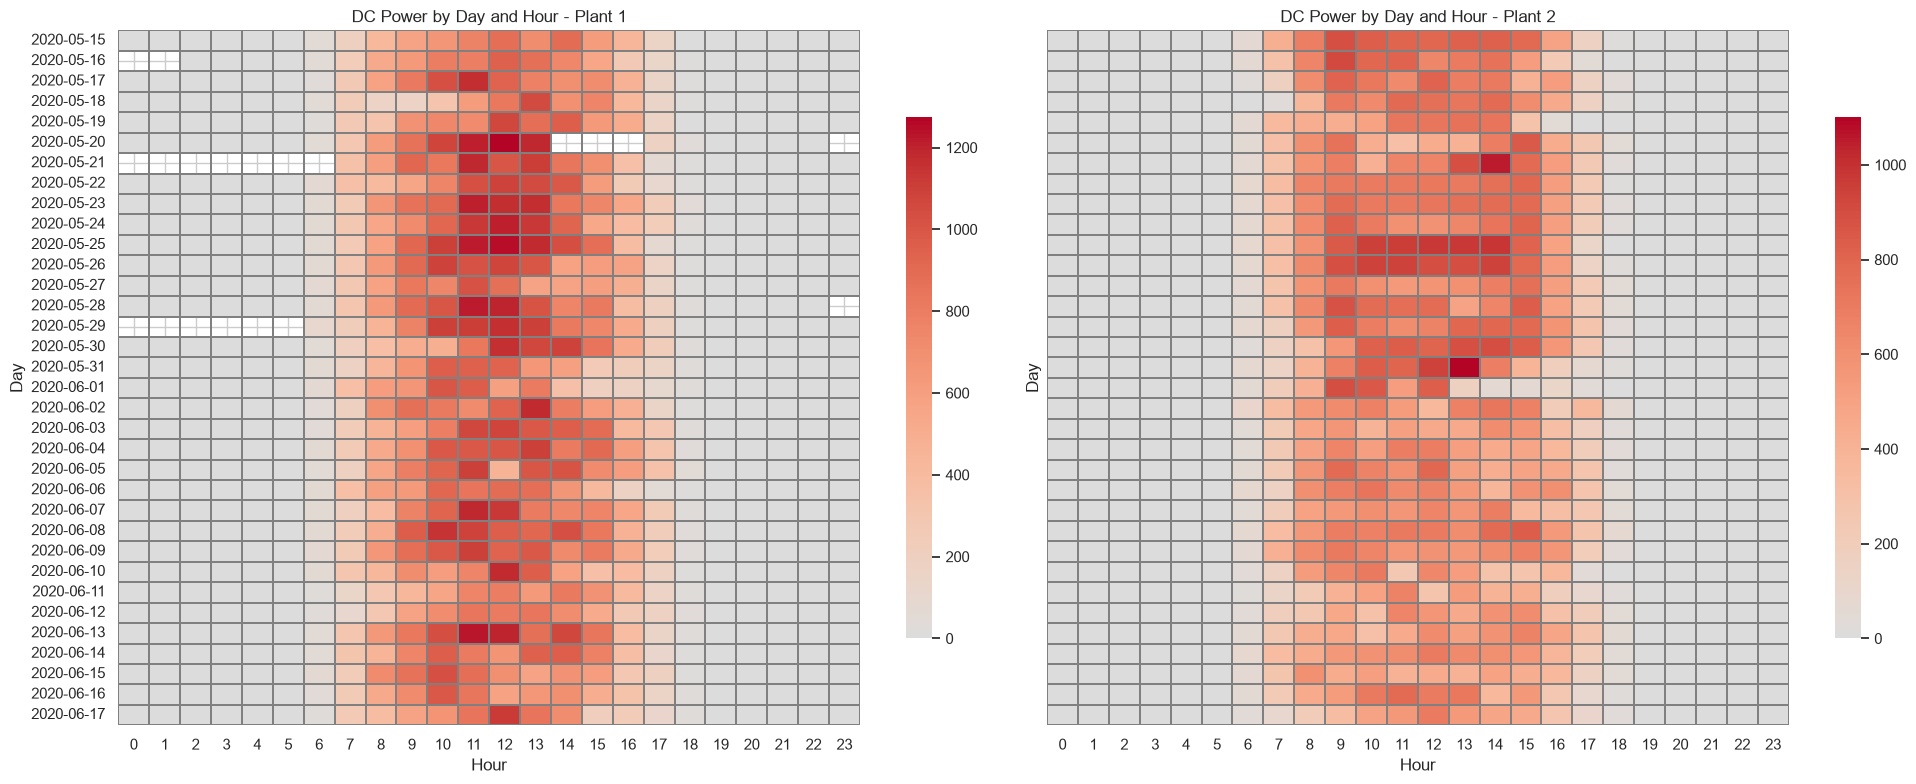

In [76]:
#Heatmaps de Potencia DC diaria por hora para las plantas 1 y 2

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

plants = {
    "Plant 1": "p1",
    "Plant 2": "p2",
}

for ax, (title, planta) in zip(axes, plants.items()):
    data_heatmap = (
        df_diario_potencia_dc[df_diario_potencia_dc["id_planta"] == planta]
        .pivot_table(
            index="fecha_dia",
            columns="hora",
            values="potencia_dc_kw"
        )
    )

    sns.heatmap(
        data_heatmap,
        ax=ax,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.2,
        linecolor="gray",
        cbar_kws={"shrink": 0.75},
        yticklabels=True
    )

    ax.set_title(f"DC Power by Day and Hour - {title}", fontsize=12)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Day")

plt.tight_layout()
plt.show()

#### Potencia DC VS Energia diaria en plantas 1 y 2

In [95]:
#Construir variable fecha a partir del indice en df
df["fecha"] = pd.to_datetime(df.index).normalize()

In [97]:
# df diario de irradiacion vs energia generada
df_diario_potencia_energia = (
    df
    .groupby(['fecha', 'id_planta'])[['potencia_dc_kw','energia_diaria_kwh']]
    .agg({
          'potencia_dc_kw': 'sum',
          'energia_diaria_kwh': 'max'
      })
    .reset_index()
)

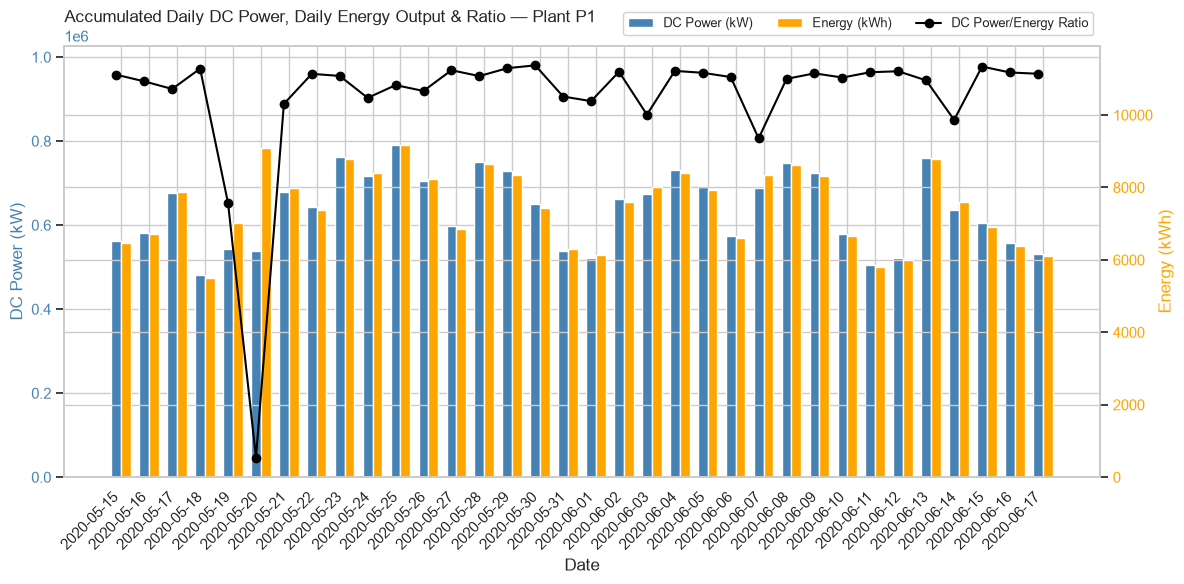

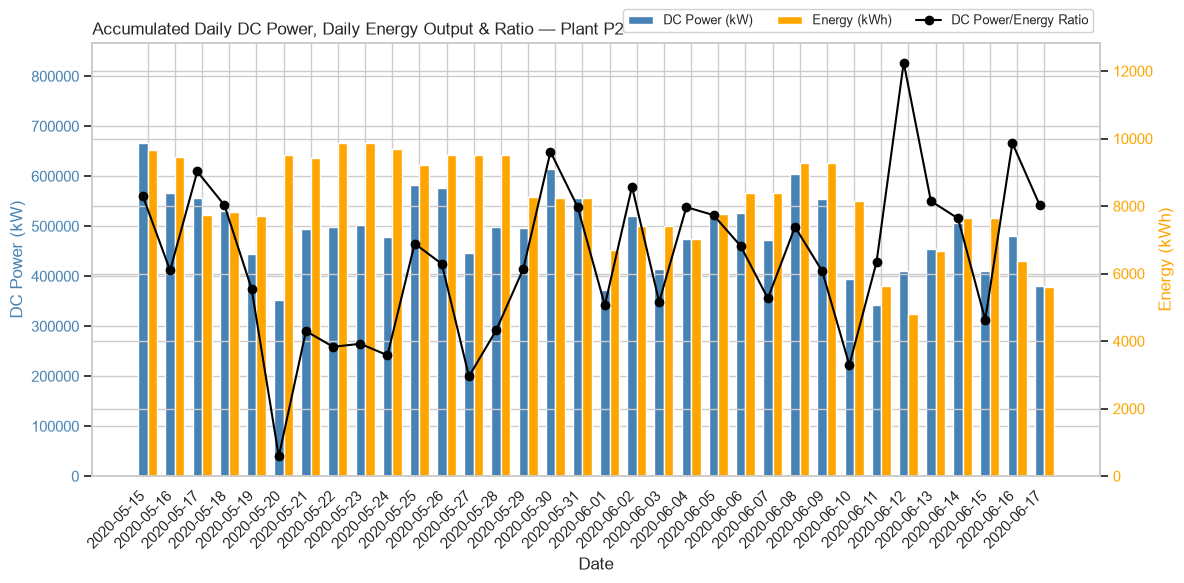

In [99]:
for planta in ['p1', 'p2']:
    df_plot = df_diario_potencia_energia[df_diario_potencia_energia['id_planta'] == planta]
    mediana_ratio = (df_plot['potencia_dc_kw'] / df_plot['energia_diaria_kwh']).median()

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.axis('off')

    bar_width = 0.35
    x = range(len(df_plot))

    ax1.bar(x, df_plot['potencia_dc_kw'], width=bar_width, label='Potencia DC (kW)', color='steelblue')
    ax1.set_ylabel("DC Power (kW)", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_ylim(0, df_plot['potencia_dc_kw'].max() * 1.3)

    ax2.bar([p + bar_width for p in x], df_plot['energia_diaria_kwh'], width=bar_width, label='Energía (kWh)', color='orange')
    ax2.set_ylabel("Energy (kWh)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(0, df_plot['energia_diaria_kwh'].max() * 1.3)

    ratio = df_plot['potencia_dc_kw'] / df_plot['energia_diaria_kwh']
    line_ratio, = ax3.plot(x, ratio, 'o-', color='black', label='Ratio Potencia/Energía')

    ax1.set_xlabel("Date")
    ax1.set_xticks([p + bar_width/2 for p in x])
    ax1.set_xticklabels(df_plot['fecha'].dt.strftime("%Y-%m-%d"), rotation=45, ha='right')

    handles = [ax1.patches[0], ax2.patches[0], line_ratio]
    labels = ['DC Power (kW)', 'Energy (kWh)', 'DC Power/Energy Ratio']
    ax1.legend(handles, labels, loc='lower right', bbox_to_anchor=(1.0, 1.01),
               ncol=3, framealpha=0.9, fontsize=9)

    ax1.set_title(f"Accumulated Daily DC Power, Daily Energy Output & Ratio — Plant {planta.upper()}", loc='left')
    plt.tight_layout()
    plt.show()

#### Análisis de anomalías en Potencia DC registrada por inverter en planta 1 y 2 en días concretos

In [100]:
#Filtros de días más anómalos
filter_p1 = (df['id_planta'] == 'p1') & (df['fecha'].isin(pd.to_datetime(['2020-05-19', '2020-05-20'])))
filter_p2 = (df['id_planta'] == 'p2') & (df['fecha'].isin(pd.to_datetime(['2020-05-20', '2020-05-27','2020-05-28','2020-06-10', '2020-06-12', '2020-06-15'])))

In [101]:
#Datasets temporales potencia DC por dia, hora y inverter
df_anomalias_inverters_p1 = df[filter_p1].groupby(['fecha', 'hora', 'id_inversor'])[['potencia_dc_kw']].mean().reset_index()
df_anomalias_inverters_p2 = df[filter_p2].groupby(['fecha', 'hora', 'id_inversor'])[['potencia_dc_kw']].mean().reset_index()

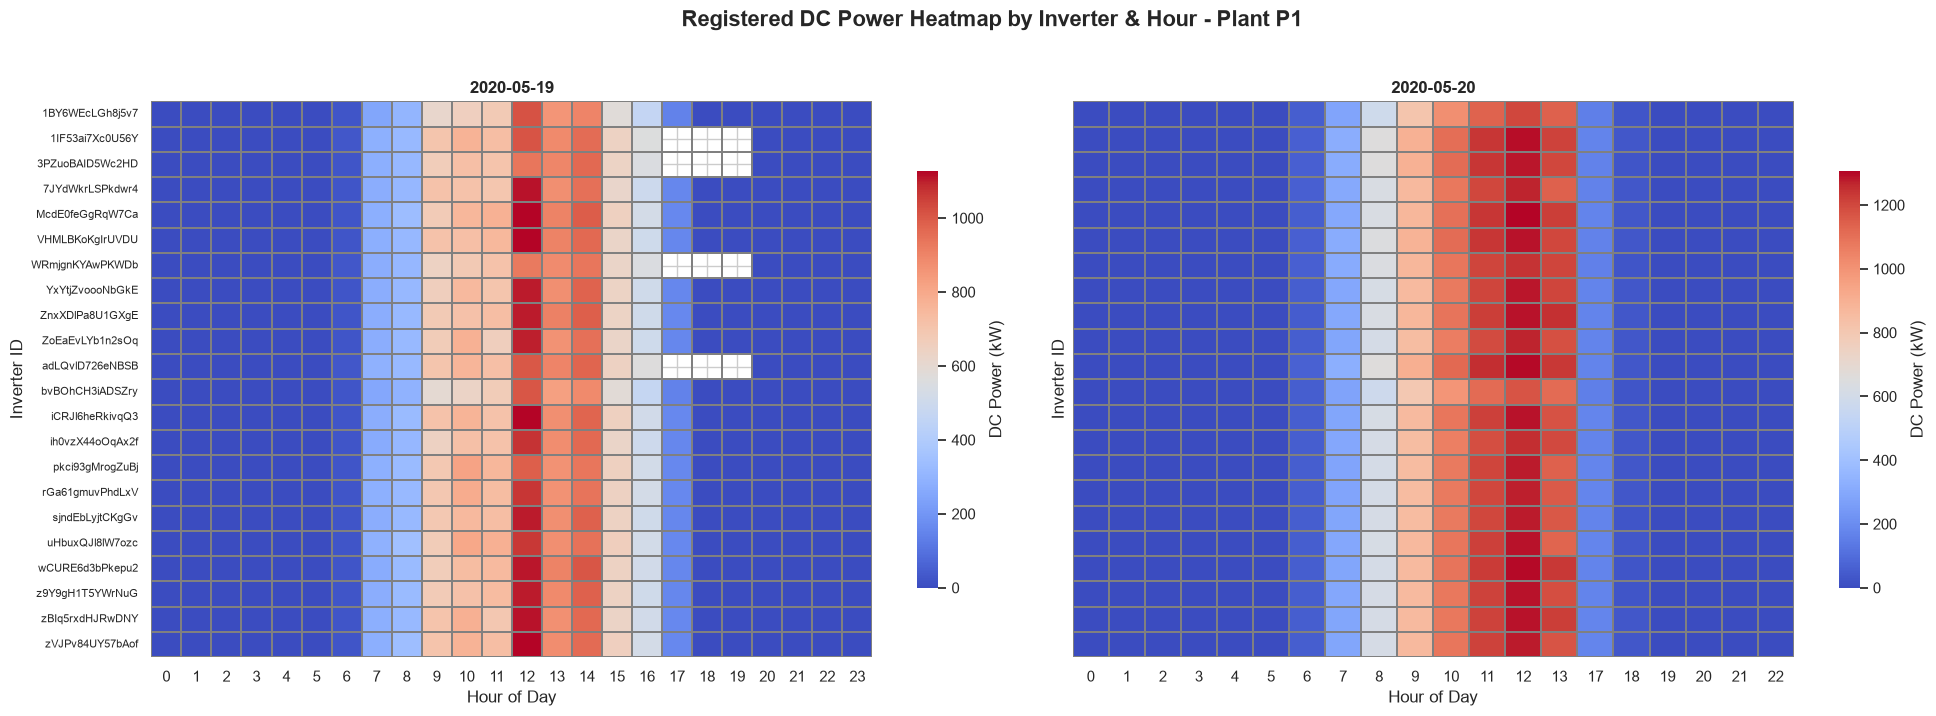

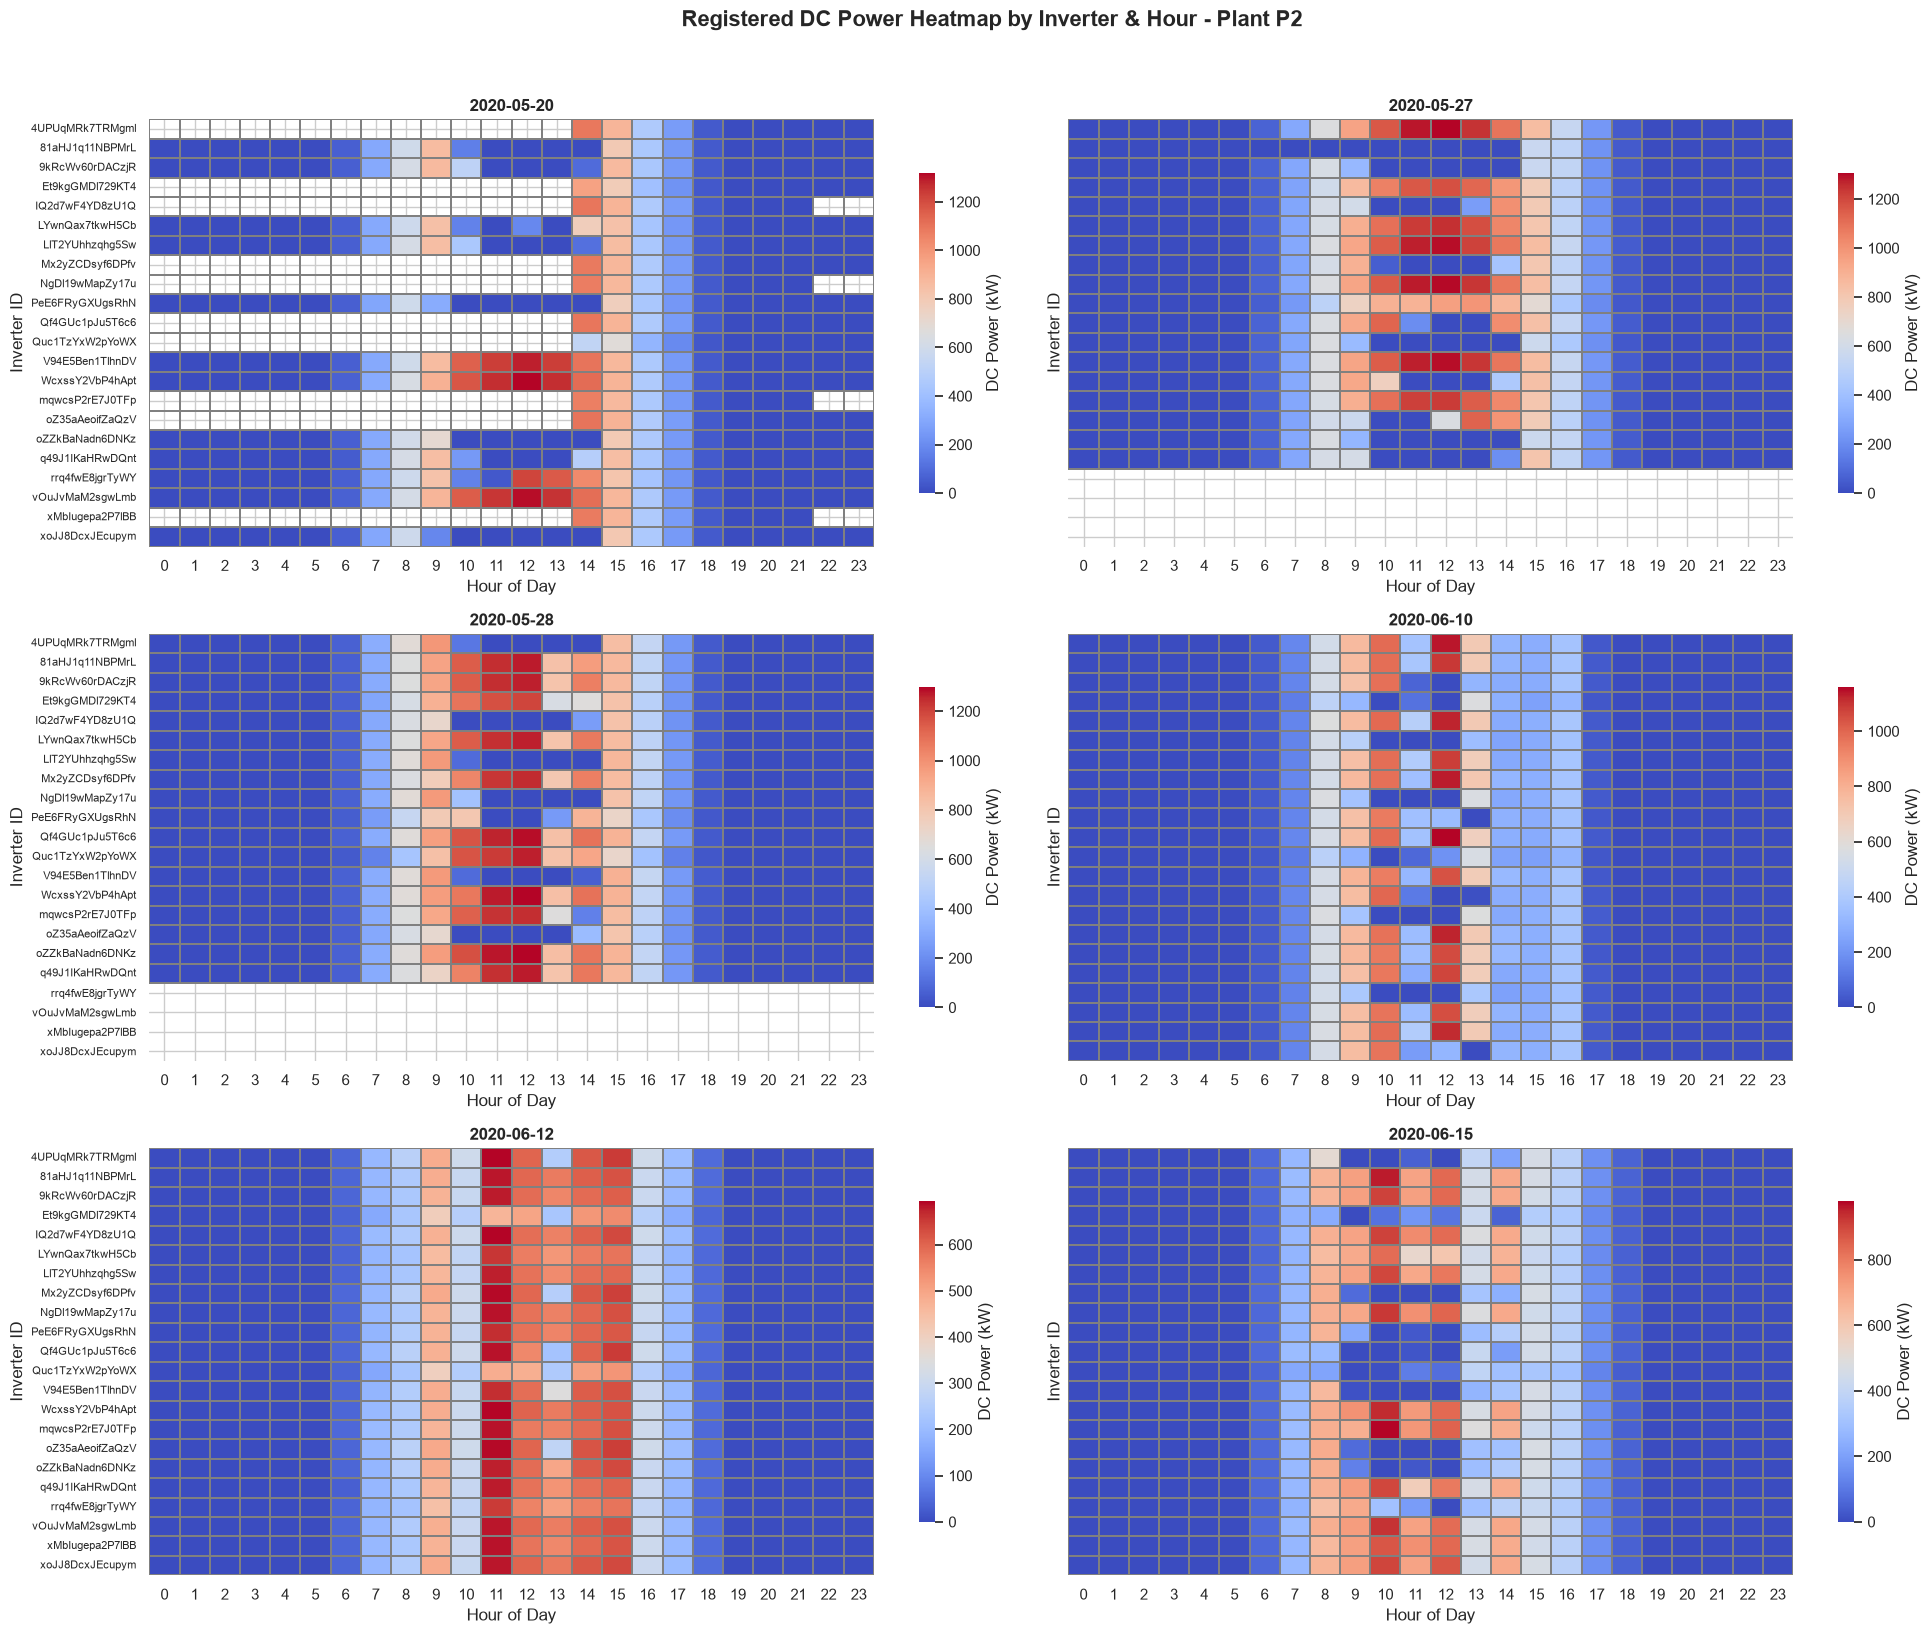

In [143]:
#Heatmaps de Potencia DC por dia, hora, inverter y planta
plot_config = {
    "p1": {
        "df": df_anomalias_inverters_p1,
        "nrows": 1,
        "ncols": 2,
        "figsize": (20, 7),
    },
    "p2": {
        "df": df_anomalias_inverters_p2,
        "nrows": 3,
        "ncols": 2,
        "figsize": (20, 16),
    },
}

for planta, config in plot_config.items():
    df_anomalias = config["df"]
    dias_unicos = sorted(df_anomalias["fecha"].unique())

    fig, axes = plt.subplots(
        config["nrows"],
        config["ncols"],
        figsize=config["figsize"],
        sharex=False,
        sharey=True
    )

    axes = axes.flatten()

    for ax, dia in zip(axes, dias_unicos):
        df_dia = df_anomalias[df_anomalias["fecha"] == dia]

        pivot_data = df_dia.pivot_table(
            index="id_inversor",
            columns="hora",
            values="potencia_dc_kw",
            aggfunc="mean"
        )

        sns.heatmap(
            pivot_data,
            ax=ax,
            cmap="coolwarm",
            annot=False,
            cbar_kws={"label": "DC Power (kW)", "shrink": 0.75},
            linewidths=0.3,
            linecolor="gray"
        )

        ax.set_title(
            f"{pd.Timestamp(dia).strftime('%Y-%m-%d')}",
            fontsize=12,
            fontweight="bold"
        )
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Inverter ID")
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0, labelsize=8)

    for ax in axes[len(dias_unicos):]:
        ax.axis("off")

    fig.suptitle(
        f"Registered DC Power Heatmap by Inverter & Hour - Plant {planta.upper()}",
        fontsize=16,
        fontweight="bold",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

### Insight 6: Fallos de medición de potencia DC/AC en los inverters
Algunos dias presentan niveles de potencia DC descorrelacionada con la energia generada. Esto indica que existen fallos en la medición de dicha potencia por parte de los inverters, descartando la existencia de fallos por desconexión de los mismos.

1. - Planta 1: fallos de medición en 4 inverters concretos el dia 19 de Mayo y fallo de medición de todos los inverters de 14 a 16h el dia 20 de Mayo.
2. - Planta 2: multiples fallos de medición en distintos dias. Se observan fallos bastante distintos tanto por rango de horas como por cantidad de inverters fallando simultaneamente.
        - Días con más fallos: 20 y 27 de Mayo y 10, 12 y 15 de Junio.

### Analisis Profundo de anomalías

#### Bloque 1 — Fallos en sensores de Irradiación

In [131]:
# Ratio de Irradiacion vs Energia Generada por día y planta
df_ratio = df.groupby(['fecha', 'id_planta']).agg(
    irradiacion=('irradiacion_wh_m2', 'sum'),
    energia=('energia_diaria_kwh', 'max')
).reset_index()

df_ratio['ratio'] = 1 - (df_ratio['irradiacion'] / df_ratio['energia'])

def clasificar_ratio(r):
    if r < (1 - 0.061) :   return 'normal'
    elif (1 - 0.059) >= r >= (1 - 0.061) : return 'minor_fault'
    else: return 'severe_fault'

df_ratio['clasificacion'] = df_ratio['ratio'].apply(clasificar_ratio)

df_ratio[df_ratio['clasificacion'] != 'normal'].sort_values('ratio', ascending=False).head(5)

,fecha,id_planta,irradiacion,energia,ratio,clasificacion
11,2020-05-20,p2,386.608390,9511.000000,0.959351,severe_fault
55,2020-06-11,p2,248.115166,5627.066667,0.955907,severe_fault
10,2020-05-20,p1,401.401929,9102.000000,0.955900,severe_fault
35,2020-06-01,p2,295.465807,6692.000000,0.955848,severe_fault
67,2020-06-17,p2,262.696826,5596.000000,0.953056,severe_fault


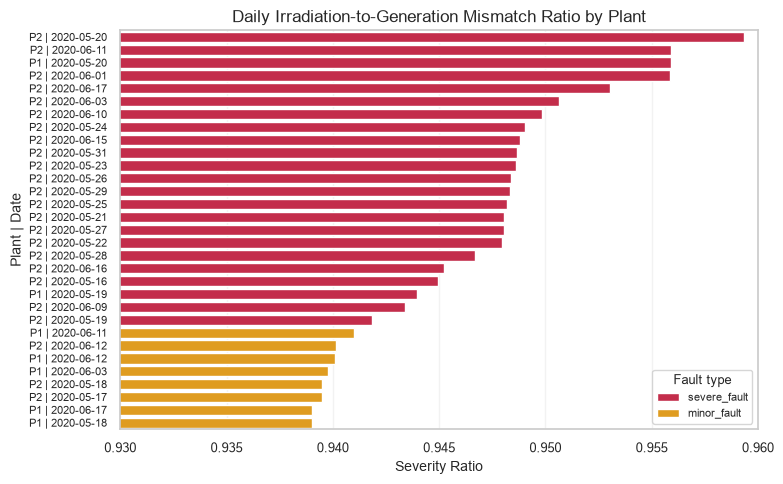

In [133]:
df_ratio_anom = (
    df_ratio[df_ratio["clasificacion"] != "normal"]
    .copy()
)

df_ratio_anom["fecha_str"] = pd.to_datetime(df_ratio_anom["fecha"]).dt.strftime("%Y-%m-%d")
df_ratio_anom["label"] = (
    df_ratio_anom["id_planta"].str.upper()
    + " | "
    + df_ratio_anom["fecha_str"]
)

# Fallos más graves arriba
df_ratio_anom = df_ratio_anom.sort_values("ratio", ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_ratio_anom,
    y="label",
    x="ratio",
    hue="clasificacion",
    palette={
        "minor_fault": "orange",
        "severe_fault": "crimson"
    },
    dodge=False
)

# Labels más pequeños para evitar solapes
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=9)

ax.set_title("Daily Irradiation-to-Generation Mismatch Ratio by Plant", fontsize=12)
ax.set_xlabel("Severity Ratio", fontsize=10)
ax.set_ylabel("Plant | Date", fontsize=10)

# Eje X fijo de 0.92 a 1
ax.set_xlim(0.93, 0.96)

ax.legend(
    title="Fault type",
    fontsize=8,
    title_fontsize=9,
    loc="lower right"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

#### Bloque 2.1 — Ausencia de registros DC por inverter/día

In [180]:
# Horario solar
HORA_INI, HORA_FIN = 6, 20

df_solar = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)]

# Registros por inverter y día
registros_inv = df_solar.groupby(['fecha', 'id_planta', 'id_inversor'])['potencia_dc_kw'].count().reset_index()
registros_inv.columns = ['fecha', 'id_planta', 'id_inversor', 'n_registros']

# Mediana de registros por día y planta (baseline)
baseline = registros_inv.groupby(['fecha', 'id_planta'])['n_registros'].median().reset_index()
baseline.columns = ['fecha', 'id_planta', 'mediana_registros']

registros_inv = registros_inv.merge(baseline, on=['fecha', 'id_planta'])
registros_inv['pct_registros'] = registros_inv['n_registros'] / registros_inv['mediana_registros']
registros_inv['fallo_ausencia'] = registros_inv['pct_registros'] < 0.5

ausencias = registros_inv[registros_inv['fallo_ausencia']].sort_values(['id_planta', 'fecha'])
print(ausencias[['fecha', 'id_planta', 'id_inversor', 'n_registros', 'mediana_registros', 'pct_registros']])

         fecha id_planta      id_inversor  n_registros  mediana_registros  \
242 2020-05-20        p2  4UPUqMRk7TRMgml           27               60.0   
245 2020-05-20        p2  Et9kgGMDl729KT4           27               60.0   
246 2020-05-20        p2  IQ2d7wF4YD8zU1Q           27               60.0   
249 2020-05-20        p2  Mx2yZCDsyf6DPfv           27               60.0   
250 2020-05-20        p2  NgDl19wMapZy17u           27               60.0   
252 2020-05-20        p2  Qf4GUc1pJu5T6c6           27               60.0   
253 2020-05-20        p2  Quc1TzYxW2pYoWX           27               60.0   
256 2020-05-20        p2  mqwcsP2rE7J0TFp           27               60.0   
257 2020-05-20        p2  oZ35aAeoifZaQzV           27               60.0   
262 2020-05-20        p2  xMbIugepa2P7lBB           27               60.0   
610 2020-05-29        p2  IQ2d7wF4YD8zU1Q           19               59.0   
614 2020-05-29        p2  NgDl19wMapZy17u           19               59.0   

#### Bloque 2.2 — Valores anómalos DC por inverter/hora/día

In [181]:
# Mediana horaria por día y planta
df_solar2 = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)].copy()

mediana_horaria = df_solar2.groupby(['fecha', 'id_planta', 'hora'])['potencia_dc_kw'].median().reset_index()
mediana_horaria.columns = ['fecha', 'id_planta', 'hora', 'mediana_potencia']

df_solar2 = df_solar2.merge(mediana_horaria, on=['fecha', 'id_planta', 'hora'])

# Anomalía: inverter con potencia < 5% de mediana, mientras mediana > 100kW
df_solar2['anomalia'] = (
    (df_solar2['potencia_dc_kw'] < df_solar2['mediana_potencia'] * 0.05) &
    (df_solar2['mediana_potencia'] > 100)
)

anomalias = df_solar2[df_solar2['anomalia']].groupby(
    ['id_planta', 'id_inversor']
).agg(
    n_horas_anomalas=('anomalia', 'sum'),
    dias_afectados=('fecha', 'nunique')
).reset_index().sort_values(['id_planta', 'n_horas_anomalas'], ascending=[True, False])

print(anomalias)

   id_planta      id_inversor  n_horas_anomalas  dias_afectados
2         p1  bvBOhCH3iADSZry                20               2
0         p1  1BY6WEcLGh8j5v7                19               2
6         p1  z9Y9gH1T5YWrNuG                 7               2
5         p1  wCURE6d3bPkepu2                 5               1
1         p1  McdE0feGgRqW7Ca                 3               1
4         p1  sjndEbLyjtCKgGv                 3               1
7         p1  zBIq5rxdHJRwDNY                 3               2
8         p1  zVJPv84UY57bAof                 2               1
3         p1  ih0vzX44oOqAx2f                 1               1
12        p2  Et9kgGMDl729KT4               294              28
14        p2  LYwnQax7tkwH5Cb               283              24
20        p2  Quc1TzYxW2pYoWX               272              27
27        p2  rrq4fwE8jgrTyWY               241              23
10        p2  81aHJ1q11NBPMrL               220              20
26        p2  q49J1IKaHRwDQnt           

#### Bloque 3 — Ranking final por inverter

In [192]:
# Combinar ausencias + anomalías
ranking_ausencias = ausencias.groupby(['id_planta', 'id_inversor']).agg(
    dias_ausencia=('fecha', 'nunique')
).reset_index()

ranking = anomalias.merge(ranking_ausencias, on=['id_planta', 'id_inversor'], how='outer').fillna(0)
ranking['score_total'] = ranking['n_horas_anomalas'] + ranking['dias_ausencia'] * 5  # peso mayor a ausencias
ranking = ranking.sort_values(['id_planta', 'score_total'], ascending=[True, False])

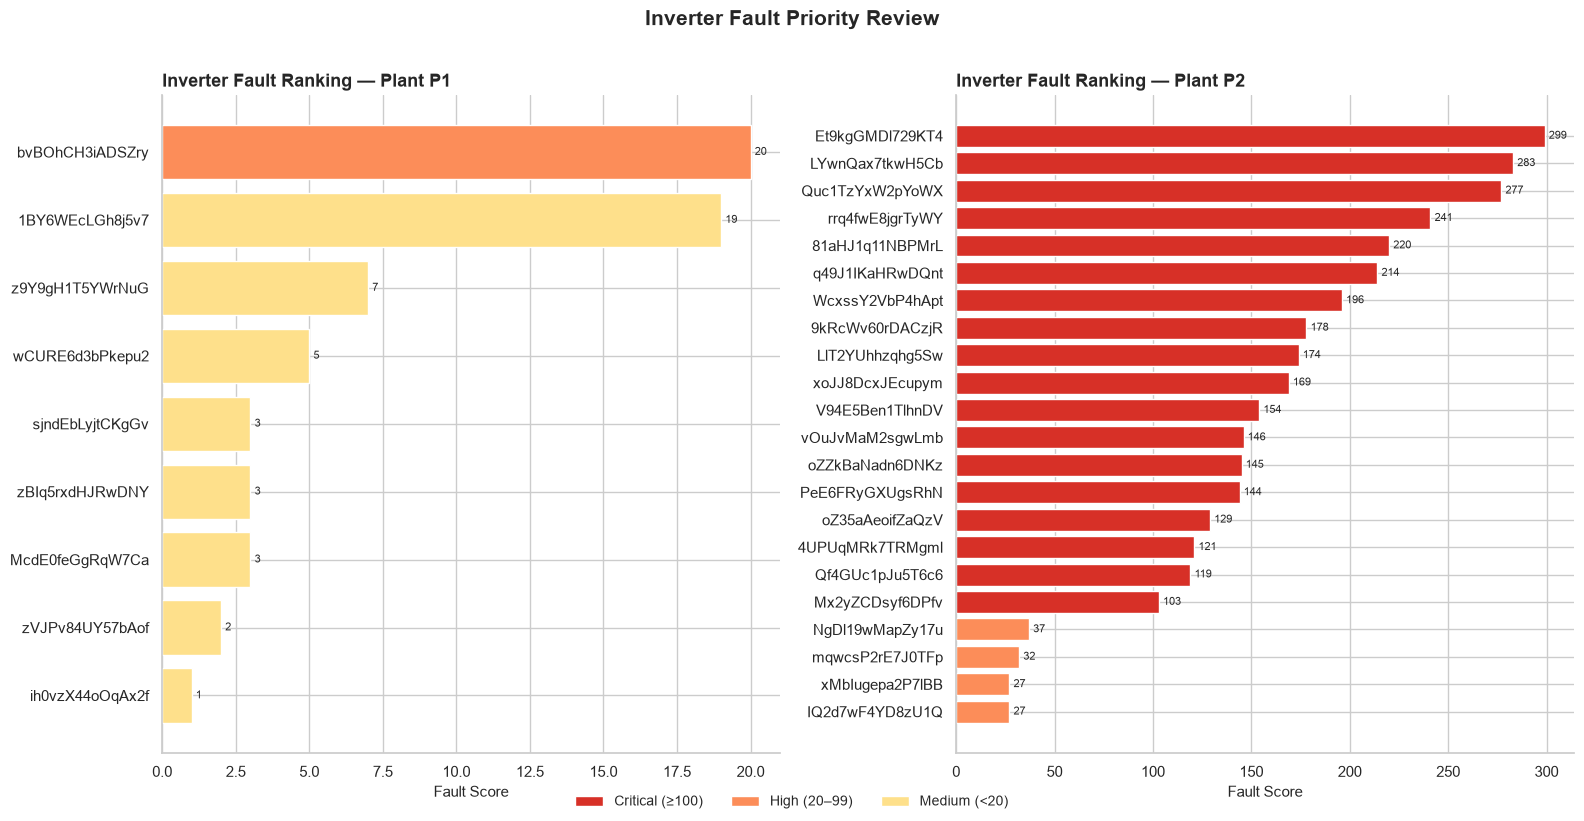

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, planta in zip(axes, ['p1', 'p2']):
    df_plot = ranking[ranking['id_planta'] == planta].sort_values('score_total')
    
    colors = ['#d73027' if s >= 100 else '#fc8d59' if s >= 20 else '#fee08b' 
              for s in df_plot['score_total']]
    
    bars = ax.barh(df_plot['id_inversor'], df_plot['score_total'], color=colors)
    ax.set_xlabel('Fault Score', fontsize=11)
    ax.set_title(f'Inverter Fault Ranking — Plant {planta.upper()}', fontsize=13, fontweight='bold', loc='left')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='Critical (≥100)'),
    Patch(facecolor='#fc8d59', label='High (20–99)'),
    Patch(facecolor='#fee08b', label='Medium (<20)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, frameon=False)

plt.suptitle('Inverter Fault Priority Review', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/graphics/inverter-fault-ranking.png', dpi=150, bbox_inches='tight')
plt.show()